# 🎵 Spotify Song Popularity Prediction
## End-to-End Machine Learning Pipeline
**Roll No:** 24030302038
**Dataset:** Spotify Tracks Dataset — 114,000 Songs
**Objective:** Predict whether a song will be High, Medium, or Low popularity based on its audio features

## Section 1: Importing Libraries, Dataset and Previewing the Dataset

In [38]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, f1_score)
from xgboost import XGBClassifier
from scipy.stats import skew
import time

# Create images folder for exporting charts
os.makedirs('images', exist_ok=True)
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [39]:
# Load Data
# Set working directory to where your files are
os.chdir(r'D:\COLLEGE\MBA\SEMESTERS\IV Semester\MBAG - 407 - MLM\Master Project')

df = pd.read_csv('Spotify_Music.csv')
print("✅ Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

✅ Dataset loaded successfully!
   Rows    : 114,000
   Columns : 21


In [40]:
print("=== FIRST 5 ROWS ===")
df.head()

=== FIRST 5 ROWS ===


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Step 1: Business Problem Framing

**Business Goal:** Record labels and music producers invest millions per release with no guarantee of commercial success. This project builds a multi-class classification model to predict whether a Spotify song will achieve High, Medium, or Low popularity based on its audio features — before release.

**ML Problem Type:** Multi-class Classification (3 classes: Low / Medium / High)

**Predicting For:** Record label A&R teams, music producers, and streaming platform editorial curators deciding where to allocate marketing investment.

**Cost of Errors:**
- **False Negative** (predict Low, actual High): Missed investment opportunity — a potential hit receives no marketing support
- **False Positive** (predict High, actual Low): Wasted marketing budget on a song that fails to chart

Missing a genuine hit is significantly more costly than over-investing in one mediocre song.

**Success Metric:** Weighted F1-Score — chosen because raw accuracy is misleading when 59% of songs are Low popularity. A model predicting "Low" for everything would score 59% accuracy while being completely useless.

### First Look at the Data

In [41]:
print("=== FIRST 5 ROWS ===")
df.head()

=== FIRST 5 ROWS ===


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Data Types & Missing Values

In [42]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print(f"\n=== DUPLICATE ROWS ===")
print(f"Duplicates: {df.duplicated().sum()}")

=== DATA TYPES ===
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

=== MISSING VALUES ===
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liv

### Popularity Score Distribution

=== POPULARITY STATISTICS ===
count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


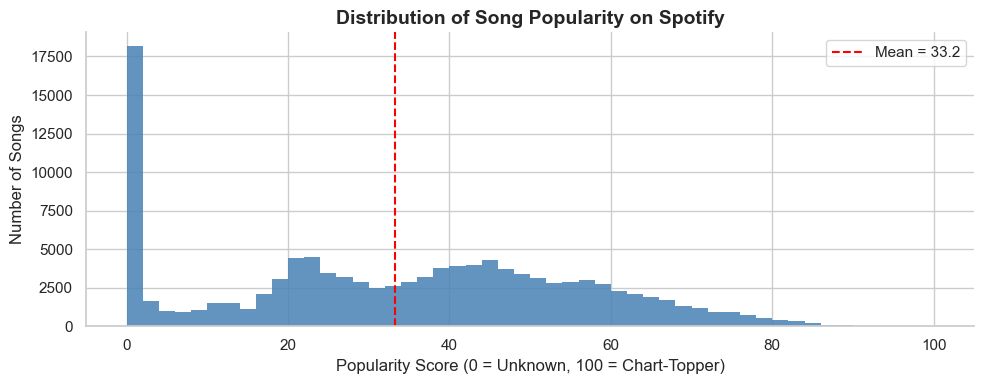

In [43]:
print("=== POPULARITY STATISTICS ===")
print(df['popularity'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['popularity'], bins=50, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean = {df['popularity'].mean():.1f}")
ax.set_title('Distribution of Song Popularity on Spotify', fontsize=14, fontweight='bold')
ax.set_xlabel('Popularity Score (0 = Unknown, 100 = Chart-Topper)')
ax.set_ylabel('Number of Songs')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('images/01_popularity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: Data Preprocessing
### 2.1 — Drop Unnecessary Columns
The following columns are identifiers only — they label a song but carry no audio signal for a model to learn from:
- `Unnamed: 0` — row number
- `track_id` — Spotify internal ID
- `artists`, `album_name`, `track_name` — text labels

In [44]:
# Dropping columns that are identifiers — not useful for ML
# Unnamed:0 = row number, track_id = Spotify ID,
# artists/album_name/track_name = text identifiers

df.drop(columns=['Unnamed: 0', 'track_id',
                 'artists', 'album_name', 'track_name'], inplace=True)
print("✅ Columns dropped successfully!")
print(f"   Remaining columns : {df.shape[1]}")
print(f"   Columns left      : {list(df.columns)}")

✅ Columns dropped successfully!
   Remaining columns : 16
   Columns left      : ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


### 2.2 — Handle Missing Values

In [45]:
print("=== MISSING VALUES BEFORE CLEANING ===")
print(df.isnull().sum())

df.dropna(inplace=True)

print(f"\n✅ Missing values handled!")
print(f"   Rows remaining: {df.shape[0]:,}")

=== MISSING VALUES BEFORE CLEANING ===
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

✅ Missing values handled!
   Rows remaining: 114,000


### 2.3 — Feature Engineering
Three new features created based on audio domain knowledge:
| New Feature | Formula | What it captures |
|-------------|---------|-----------------|
| `duration_min` | duration_ms ÷ 60000 | Song length in minutes — more interpretable |
| `energy_acoustic_ratio` | energy ÷ (acousticness + 0.001) | Electronic vs acoustic style |
| `dance_energy` | danceability × energy | Songs high on BOTH — the pop/EDM signature |

In [46]:
# 1. Convert duration from milliseconds to minutes
df['duration_min'] = df['duration_ms'] / 60000
df.drop(columns=['duration_ms'], inplace=True)

# 2. Convert explicit from True/False to 1/0
df['explicit'] = df['explicit'].astype(int)

# 3. Energy-to-acousticness ratio
# High energy + low acousticness = electronic/pop style
# +0.001 prevents division by zero
df['energy_acoustic_ratio'] = df['energy'] / (df['acousticness'] + 0.001)

# 4. Danceability × Energy interaction
# Songs that are BOTH danceable AND energetic simultaneously
df['dance_energy'] = df['danceability'] * df['energy']

print("✅ Feature engineering complete!")
print(f"   New features : duration_min, energy_acoustic_ratio, dance_energy")
print(f"   Total columns now : {df.shape[1]}")

✅ Feature engineering complete!
   New features : duration_min, energy_acoustic_ratio, dance_energy
   Total columns now : 18


### 2.4 — Create Target Variable (Popularity Category)
The continuous 0–100 popularity score is converted into 3 business-meaningful classes:
| Category | Score Range | Meaning | Count |
|----------|-------------|---------|-------|
| Low | 0–40 | Niche / undiscovered | ~59% |
| Medium | 41–65 | Mainstream | ~33% |
| High | 66–100 | Chart-toppers | ~7.5% |

Bins are based on the distribution in Cell 8 — the mean is 33.2, confirming the majority of songs are undiscovered.

=== TARGET VARIABLE DISTRIBUTION ===
popularity_category
Low       67326
Medium    38149
High       8525
Name: count, dtype: int64

Percentage breakdown:
popularity_category
Low       59.1
Medium    33.5
High       7.5
Name: proportion, dtype: float64


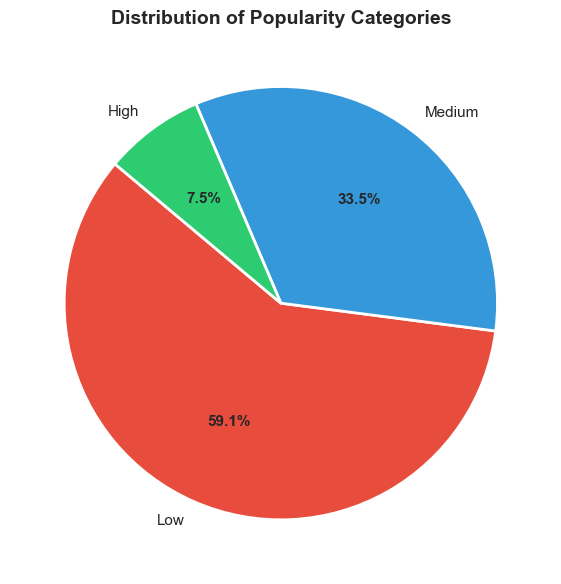

In [47]:
def categorise_popularity(score):
    if score <= 40:
        return 'Low'
    elif score <= 65:
        return 'Medium'
    else:
        return 'High'

df['popularity_category'] = df['popularity'].apply(categorise_popularity)
df.drop(columns=['popularity'], inplace=True)

print("=== TARGET VARIABLE DISTRIBUTION ===")
print(df['popularity_category'].value_counts())
print(f"\nPercentage breakdown:")
print(df['popularity_category'].value_counts(normalize=True).mul(100).round(1))

counts  = df['popularity_category'].value_counts()
colors  = ['#e74c3c', '#3498db', '#2ecc71']
labels_order = ['Low', 'Medium', 'High']
sizes   = [counts[l] for l in labels_order]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_order, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

ax.set_title('Distribution of Popularity Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/02_target_category_pie.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 — Genre Consolidation + Encoding

**Problem with raw genre encoding:**
- Label Encoding (0–113): Creates false ordinal relationships (implies Rock > Pop mathematically).
- One-Hot Encoding (114 genres): Adds 113 sparse binary columns, hurting LinearSVC performance.

**Solution — Genre Consolidation:**
114 specific genres are grouped into 5 musically meaningful macro-categories.
Then One-Hot Encoded → only 4 binary columns (drop='first').
This is correct for nominal data, interpretable, and avoids dimensionality issues.

In [48]:
# ── Define the 5 macro genre groups ───────────────────────────────────
genre_groups = {
    'Pop & Mainstream': [
        'pop', 'k-pop', 'j-pop', 'indie-pop', 'synth-pop', 'cantopop',
        'mandopop', 'power-pop', 'pop-film', 'dance', 'disco', 'party',
        'j-idol', 'j-dance', 'philippines-opm', 'swedish', 'british',
        'happy', 'summer', 'romance', 'work-out', 'road-trip'
    ],
    'Rock & Metal': [
        'rock', 'alt-rock', 'alternative', 'hard-rock', 'heavy-metal',
        'metal', 'black-metal', 'death-metal', 'grunge', 'punk',
        'punk-rock', 'emo', 'metalcore', 'j-rock', 'psych-rock',
        'rock-n-roll', 'grindcore', 'hardcore', 'rockabilly',
        'metal-misc', 'goth', 'guitar', 'bluegrass'
    ],
    'Electronic & Dance': [
        'edm', 'house', 'techno', 'trance', 'dubstep', 'electronic',
        'club', 'detroit-techno', 'deep-house', 'progressive-house',
        'drum-and-bass', 'hardstyle', 'minimal-techno', 'electro',
        'garage', 'idm', 'industrial', 'trip-hop', 'chicago-soul',
        'groove'
    ],
    'Hip-Hop R&B & Urban': [
        'hip-hop', 'r-n-b', 'reggae', 'reggaeton', 'dancehall',
        'funk', 'soul', 'afrobeat', 'dub', 'latin', 'latino', 
        'salsa', 'sertanejo', 'pagode', 'samba', 'forro', 'mpb', 'brazil'
    ]
    # Everything else → 'Other' (assigned as default below)
}

# ── Build reverse lookup: specific genre → macro group ────────────────
genre_to_macro = {}
for macro, genres in genre_groups.items():
    for g in genres:
        genre_to_macro[g] = macro

# ── Map each song's genre to its macro group ──────────────────────────
df['genre_macro'] = df['track_genre'].map(genre_to_macro).fillna('Other')

# ── Drop original genre column ────────────────────────────────────────
df.drop(columns=['track_genre'], inplace=True)

# ── One-Hot Encode the 5 macro groups ─────────────────────────────────
# drop='first' → 4 binary columns (5th is implicit reference = 'Other')
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=np.int8)
macro_encoded = ohe.fit_transform(df[['genre_macro']])

macro_columns = [f"genre_{cat.replace(' ', '_').replace('&', 'and')}" 
                 for cat in ohe.categories_[0][1:]]

macro_df = pd.DataFrame(macro_encoded, columns=macro_columns, index=df.index)
df = pd.concat([df.drop(columns=['genre_macro']), macro_df], axis=1)

print(f"✅ One-Hot Encoding of macro genres complete!")
print(f"   Macro groups     : 5")
print(f"   Columns added    : {len(macro_columns)} (4 after drop='first')")
print(f"   Reference group  : Other (implicit — all genre columns = 0)")
print(f"   New columns      : {macro_columns}")
print(f"   Total columns    : {df.shape[1]}")

✅ One-Hot Encoding of macro genres complete!
   Macro groups     : 5
   Columns added    : 4 (4 after drop='first')
   Reference group  : Other (implicit — all genre columns = 0)
   New columns      : ['genre_Hip-Hop_RandB_and_Urban', 'genre_Other', 'genre_Pop_and_Mainstream', 'genre_Rock_and_Metal']
   Total columns    : 21


### 2.6 — Encode Target Variable
The target categories are encoded as integers for sklearn compatibility.
This IS correct Label Encoding because Low / Medium / High have a genuine natural order.

In [49]:
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['target'] = df['popularity_category'].map(target_mapping)
df.drop(columns=['popularity_category'], inplace=True)

print("=== TARGET ENCODING ===")
print("Low    → 0")
print("Medium → 1")
print("High   → 2")
print(f"\n{df['target'].value_counts().sort_index()}")

=== TARGET ENCODING ===
Low    → 0
Medium → 1
High   → 2

target
0    67326
1    38149
2     8525
Name: count, dtype: int64


### 2.7 — Final Preprocessed Dataset

In [50]:
print("=== FINAL DATASET SHAPE ===")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# Separate genre columns from other features for clarity
genre_cols     = [c for c in df.columns if c.startswith('genre_')]
non_genre_cols = [c for c in df.columns 
                  if not c.startswith('genre_') and c != 'target']

print(f"\n=== NON-GENRE FEATURE COLUMNS ({len(non_genre_cols)}) ===")
for col in non_genre_cols:
    print(f"  ✅ {col}")

print(f"\n=== GENRE COLUMNS ({len(genre_cols)}) ===")
print(f"  ✅ {genre_cols}")

print(f"\n=== TARGET ===")
print(f"  ✅ target")

print("\n=== FIRST 3 ROWS (non-genre columns only) ===")
df[non_genre_cols + ['target']].head(3)

=== FINAL DATASET SHAPE ===
Rows    : 114,000
Columns : 21

=== NON-GENRE FEATURE COLUMNS (16) ===
  ✅ explicit
  ✅ danceability
  ✅ energy
  ✅ key
  ✅ loudness
  ✅ mode
  ✅ speechiness
  ✅ acousticness
  ✅ instrumentalness
  ✅ liveness
  ✅ valence
  ✅ tempo
  ✅ time_signature
  ✅ duration_min
  ✅ energy_acoustic_ratio
  ✅ dance_energy

=== GENRE COLUMNS (4) ===
  ✅ ['genre_Hip-Hop_RandB_and_Urban', 'genre_Other', 'genre_Pop_and_Mainstream', 'genre_Rock_and_Metal']

=== TARGET ===
  ✅ target

=== FIRST 3 ROWS (non-genre columns only) ===


,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min,energy_acoustic_ratio,dance_energy,target
0,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,3.844433,13.885542,0.311636,2
1,0,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,2.493500,0.179459,0.069720,1
2,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,3.513767,1.701422,0.157242,1


## Step 3: Exploratory Data Analysis (EDA)
Every chart leads to either a **business insight** or a **modeling decision**.

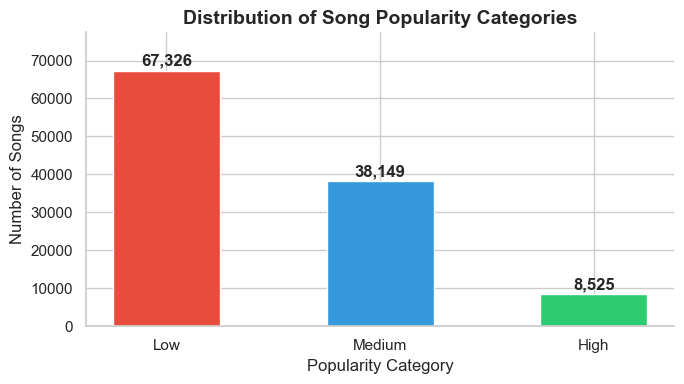

In [51]:
cat_counts = df['target'].value_counts().sort_index()
labels = ['Low', 'Medium', 'High']
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, cat_counts.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Distribution of Song Popularity Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Popularity Category')
ax.set_ylabel('Number of Songs')
ax.set_ylim(0, cat_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('images/03_category_bar.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Insight: Only 7.5% of songs qualify as High popularity.
- Modeling decision: class_weight='balanced' and Weighted F1 as primary metric.

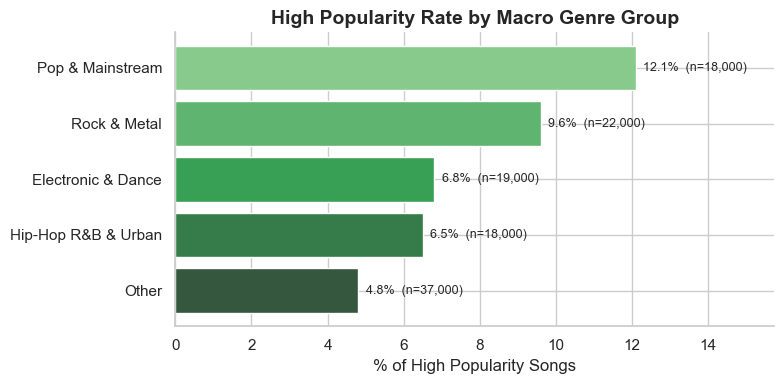

In [52]:
# Chart 2: Popularity rate by Macro Genre Group
genre_results = []
genre_cols = [c for c in df.columns if c.startswith('genre_')]

for col in genre_cols:
    # Clean up the name for the chart
    genre_name = col.replace('genre_', '').replace('_', ' ').replace('and', '&')
    total = df[df[col] == 1].shape[0]
    high  = df[(df[col] == 1) & (df['target'] == 2)].shape[0]
    if total > 0:
        genre_results.append({'genre': genre_name, 
                              'pct_high': round(high/total*100, 1), 
                              'total': total})

# The dropped reference category (Electronic & Dance) occurs when all OHE columns are 0
ref_mask = df[genre_cols].sum(axis=1) == 0
ref_total = ref_mask.sum()
ref_high  = df[ref_mask & (df['target'] == 2)].shape[0]
if ref_total > 0:
    genre_results.append({'genre': 'Electronic & Dance', 
                          'pct_high': round(ref_high/ref_total*100, 1), 
                          'total': ref_total})

genre_df_plot = pd.DataFrame(genre_results).sort_values('pct_high', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = sns.color_palette('Greens_d', len(genre_df_plot))
bars = ax.barh(genre_df_plot['genre'], genre_df_plot['pct_high'], color=colors_bar)

for bar, val, total in zip(bars, genre_df_plot['pct_high'], genre_df_plot['total']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (n={total:,})', va='center', fontsize=9)

ax.set_title('High Popularity Rate by Macro Genre Group', fontsize=14, fontweight='bold')
ax.set_xlabel('% of High Popularity Songs')
ax.invert_yaxis()
ax.set_xlim(0, genre_df_plot['pct_high'].max() * 1.3)
sns.despine()
plt.tight_layout()
plt.savefig('images/04_genre_macro_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Insight: Pop & Mainstream heavily dominates chart success.
- Business implication: Genre selection at signing is the highest-leverage decision.

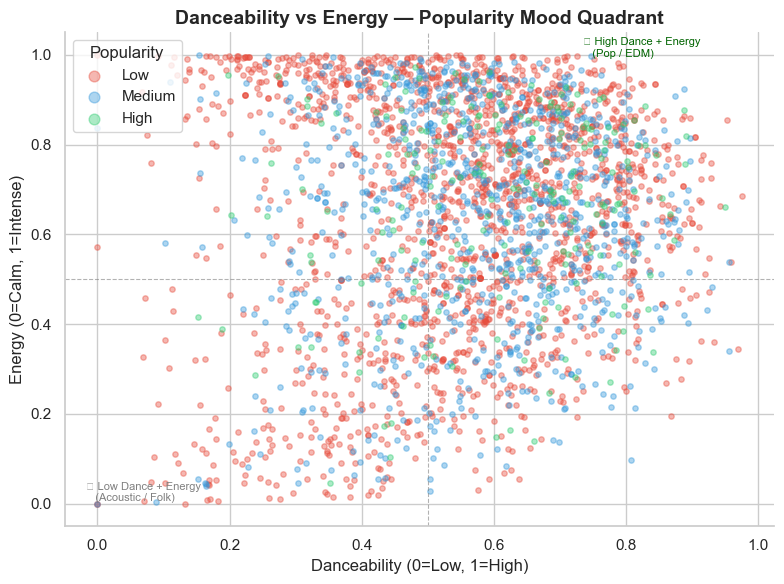

In [ ]:
# Chart 3: Danceability vs Energy — The Mood Quadrant
sample = df.sample(3000, random_state=42).copy()
pop_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
colors_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}

fig, ax = plt.subplots(figsize=(8, 6))
for target_val, label in pop_labels.items():
    mask = sample['target'] == target_val
    ax.scatter(sample.loc[mask, 'danceability'], sample.loc[mask, 'energy'],
               c=colors_map[target_val], label=label, alpha=0.4, s=15)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax.text(0.73, 0.95, '🔥 High Dance + Energy\n   (Pop / EDM)', transform=ax.transAxes, fontsize=8, color='darkgreen')
ax.text(0.03, 0.05, '🎸 Low Dance + Energy\n   (Acoustic / Folk)', transform=ax.transAxes, fontsize=8, color='gray')

ax.set_title('Danceability vs Energy — Popularity Mood Quadrant', fontsize=14, fontweight='bold')
ax.set_xlabel('Danceability (0=Low, 1=High)')
ax.set_ylabel('Energy (0=Calm, 1=Intense)')
ax.legend(title='Popularity', loc='upper left', markerscale=2)
sns.despine()
plt.tight_layout()
plt.savefig('images/05_mood_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Insight: High popularity songs concentrate in the top-right quadrant.
- Validates the dance_energy interaction feature created in preprocessing.

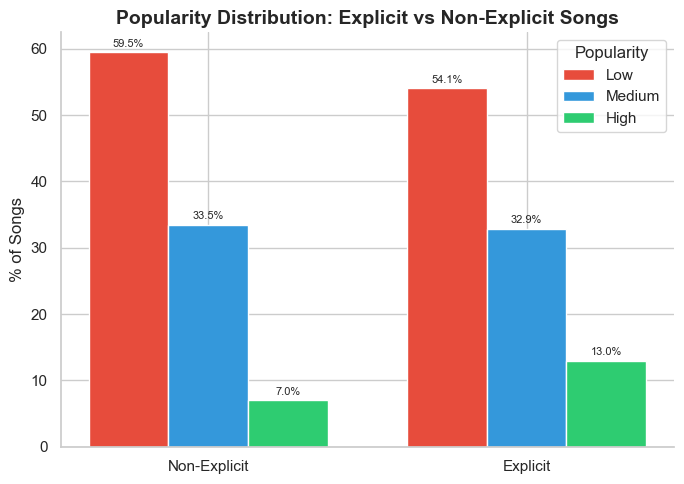

In [54]:
# Chart 4: Explicit vs Non-Explicit — Does it Matter?
explicit_df = df.groupby(['explicit', 'target']).size().reset_index(name='count')
totals = explicit_df.groupby('explicit')['count'].transform('sum')
explicit_df['pct'] = (explicit_df['count'] / totals * 100).round(1)
explicit_df['explicit_label'] = explicit_df['explicit'].map({0: 'Non-Explicit', 1: 'Explicit'})

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.25
colors = ['#e74c3c', '#3498db', '#2ecc71']
pop_labels = ['Low', 'Medium', 'High']

for i, (pop_val, color, label) in enumerate(zip([0, 1, 2], colors, pop_labels)):
    vals = explicit_df[explicit_df['target'] == pop_val]['pct'].values
    bars = ax.bar(x + i * width, vals, width, label=label, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(['Non-Explicit', 'Explicit'])
ax.set_title('Popularity Distribution: Explicit vs Non-Explicit Songs', fontsize=14, fontweight='bold')
ax.set_ylabel('% of Songs')
ax.legend(title='Popularity')
sns.despine()
plt.tight_layout()
plt.savefig('images/06_explicit_vs_nonexplicit.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Insight: Explicit songs achieve High popularity at 13% vs 7% for non-explicit.
- Business implication: Suppressing explicit content may halve mainstream appeal.

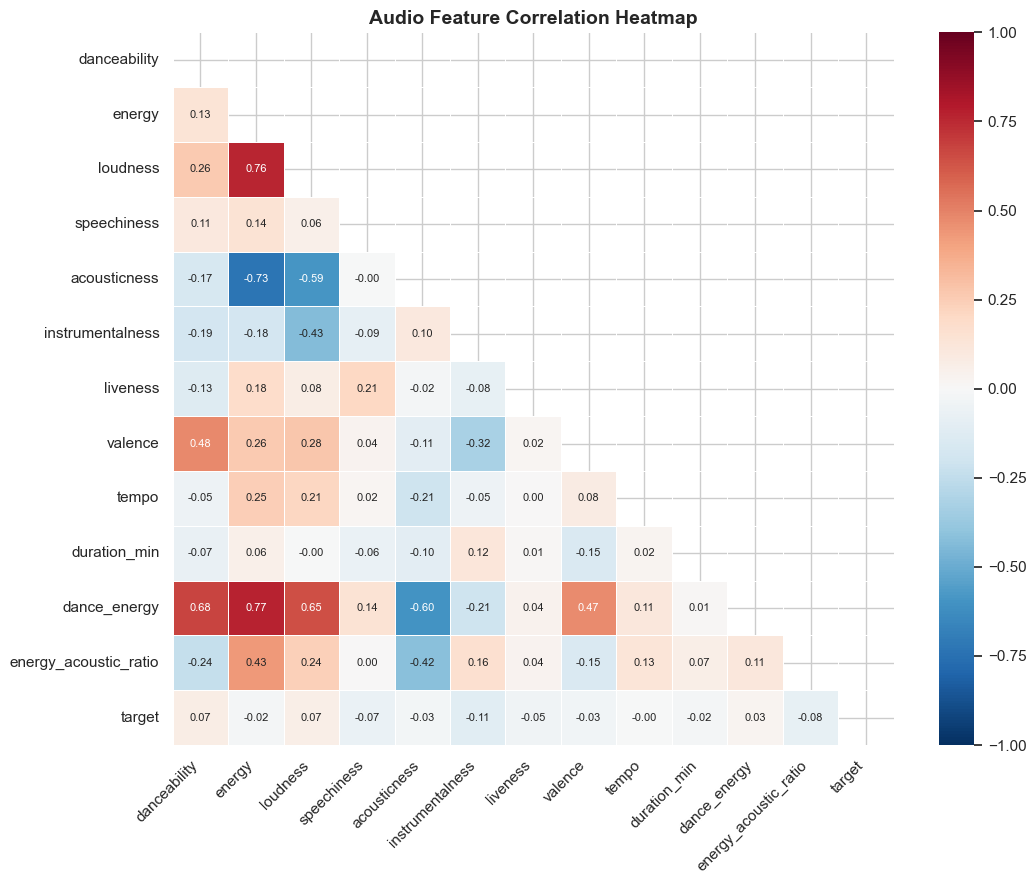

In [55]:
# Chart 5: Audio Feature Correlation Heatmap
# Only continuous audio features for correlation — not the sparse genre columns
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo', 'duration_min',
                  'dance_energy', 'energy_acoustic_ratio', 'target']

corr = df[audio_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 8})

ax.set_title('Audio Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Insight: Energy–Acousticness correlation = −0.73 (strong negative).
- High energy songs are almost never acoustic — validates energy_acoustic_ratio feature.
- All target correlations are near zero — confirms this is a non-linear problem.

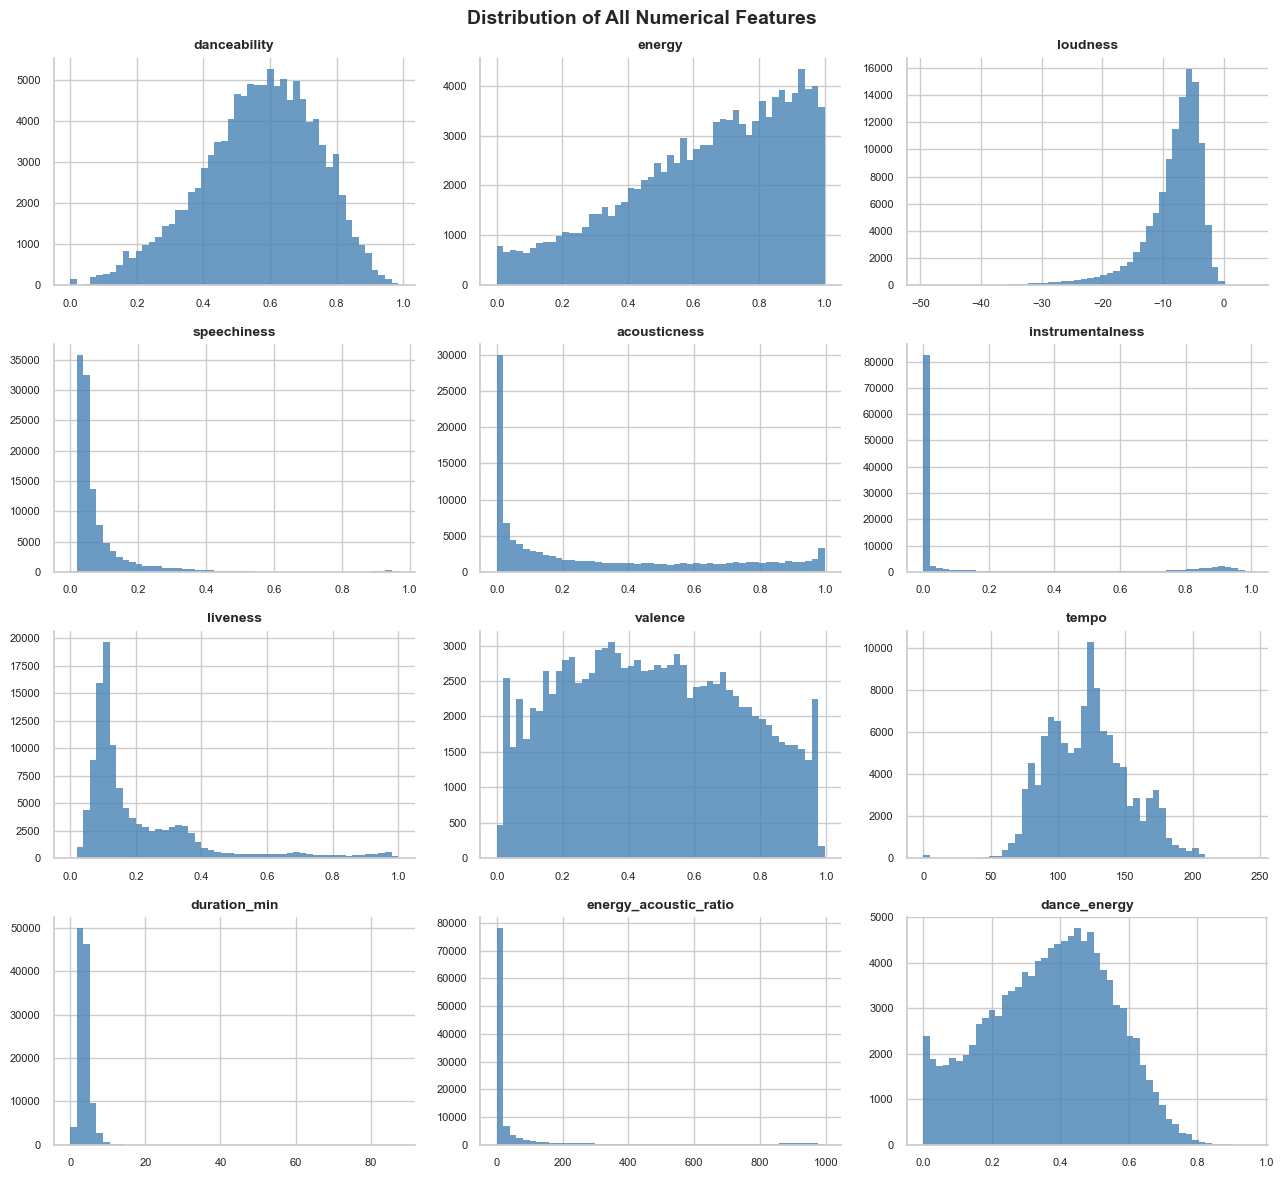

In [56]:
# Feature Distribution Analysis
numerical_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo', 'duration_min',
                  'energy_acoustic_ratio', 'dance_energy']

fig, axes = plt.subplots(4, 3, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)
    sns.despine(ax=axes[i])

fig.suptitle('Distribution of All Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/08_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# Skewness Check + Action Plan
skew_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Skewness': [round(skew(df[col]), 2) for col in numerical_cols]
}).sort_values('Skewness', ascending=False)

print("=== SKEWNESS REPORT ===")
print("(|skew| > 1 = highly skewed → may need transformation)\n")
print(skew_df.to_string(index=False))

print("\n=== FEATURES REQUIRING ATTENTION ===")
for _, row in skew_df.iterrows():
    if abs(row['Skewness']) > 1:
        print(f"  ⚠️  {row['Feature']:30s} skew = {row['Skewness']}")

=== SKEWNESS REPORT ===
(|skew| > 1 = highly skewed → may need transformation)

              Feature  Skewness
         duration_min     11.20
          speechiness      4.65
energy_acoustic_ratio      2.55
             liveness      2.11
     instrumentalness      1.73
         acousticness      0.73
                tempo      0.23
              valence      0.12
         dance_energy     -0.14
         danceability     -0.40
               energy     -0.60
             loudness     -2.01

=== FEATURES REQUIRING ATTENTION ===
  ⚠️  duration_min                   skew = 11.2
  ⚠️  speechiness                    skew = 4.65
  ⚠️  energy_acoustic_ratio          skew = 2.55
  ⚠️  liveness                       skew = 2.11
  ⚠️  instrumentalness               skew = 1.73
  ⚠️  loudness                       skew = -2.01


=== INSTRUMENTALNESS DISTRIBUTION ===
% of songs with instrumentalness < 0.01 (vocal songs)  : 70.2%
% of songs with instrumentalness > 0.5  (instrumental) : 16.5%

✅ Created binary feature: is_instrumental


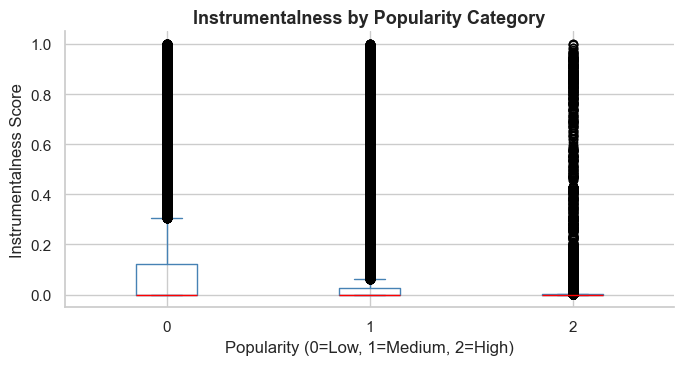

In [58]:
# Instrumentelness Deep Dive
print("=== INSTRUMENTALNESS DISTRIBUTION ===")
pct_near_zero = (df['instrumentalness'] < 0.01).mean() * 100
pct_high      = (df['instrumentalness'] > 0.5).mean()  * 100

print(f"% of songs with instrumentalness < 0.01 (vocal songs)  : {pct_near_zero:.1f}%")
print(f"% of songs with instrumentalness > 0.5  (instrumental) : {pct_high:.1f}%")

df['is_instrumental'] = (df['instrumentalness'] > 0.5).astype(int)
print(f"\n✅ Created binary feature: is_instrumental")

fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='instrumentalness', by='target', ax=ax,
           color=dict(boxes='steelblue', whiskers='steelblue', medians='red', caps='steelblue'))
ax.set_title('Instrumentalness by Popularity Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Popularity (0=Low, 1=Medium, 2=High)')
ax.set_ylabel('Instrumentalness Score')
plt.suptitle('')
sns.despine()
plt.tight_layout()
plt.savefig('images/09_instrumentalness_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Insight: 70%+ songs are vocal (instrumentalness < 0.01).
- Decision: Replace skewed continuous value with is_instrumental binary flag.

=== KEY DISTRIBUTION ===
key
0     13061
1     10772
2     11644
3      3570
4      9008
5      9368
6      7921
7     13245
8      7360
9     11313
10     7456
11     9282
Name: count, dtype: int64

=== TIME SIGNATURE DISTRIBUTION ===
% of songs in 4/4 time: 89.3%


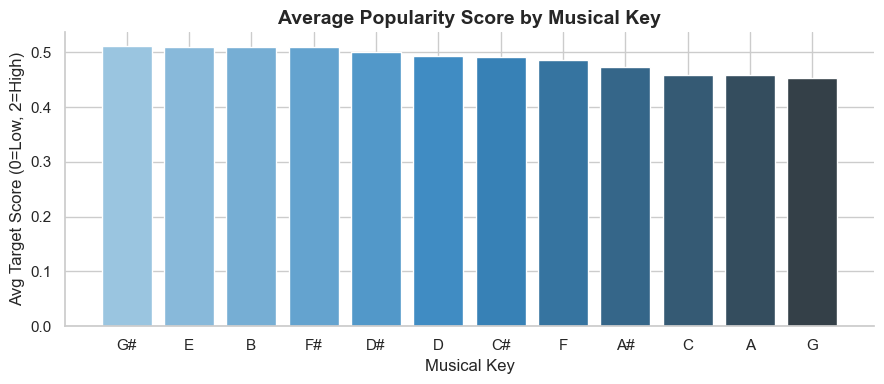

In [59]:
# Key vs. Popularity
print("=== KEY DISTRIBUTION ===")
print(df['key'].value_counts().sort_index())

print(f"\n=== TIME SIGNATURE DISTRIBUTION ===")
pct_4_4 = (df['time_signature'] == 4).mean() * 100
print(f"% of songs in 4/4 time: {pct_4_4:.1f}%")

key_names = {0:'C', 1:'C#', 2:'D', 3:'D#', 4:'E',  5:'F',
             6:'F#', 7:'G', 8:'G#', 9:'A', 10:'A#', 11:'B'}
df['key_name'] = df['key'].map(key_names)

key_pop = df.groupby('key_name')['target'].mean().reset_index()
key_pop.columns = ['key', 'avg_score']
key_pop = key_pop.sort_values('avg_score', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(key_pop['key'], key_pop['avg_score'], color=sns.color_palette('Blues_d', len(key_pop)))
ax.set_title('Average Popularity Score by Musical Key', fontsize=14, fontweight='bold')
ax.set_xlabel('Musical Key')
ax.set_ylabel('Avg Target Score (0=Low, 2=High)')
sns.despine()
plt.tight_layout()
plt.savefig('images/10_key_vs_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['key_name'], inplace=True)

📊 Insight: All 12 keys show near-identical popularity scores (range 0.46–0.51).
- Musical key has no meaningful impact on commercial success.

In [60]:
# energy_acoustic_ratio Outlier Check
print("=== ENERGY_ACOUSTIC_RATIO STATS ===")
print(df['energy_acoustic_ratio'].describe())

pct_extreme = (df['energy_acoustic_ratio'] > 50).mean() * 100
print(f"\n% of rows with ratio > 50 (extreme outliers): {pct_extreme:.1f}%")

cap_val = df['energy_acoustic_ratio'].quantile(0.99)
df['energy_acoustic_ratio'] = df['energy_acoustic_ratio'].clip(upper=cap_val)

print(f"\n✅ Capped energy_acoustic_ratio at 99th percentile: {cap_val:.2f}")
print(df['energy_acoustic_ratio'].describe())

=== ENERGY_ACOUSTIC_RATIO STATS ===
count    114000.000000
mean        103.004614
std         230.711826
min           0.000000
25%           0.913223
50%           3.985326
75%          42.541873
max         996.923323
Name: energy_acoustic_ratio, dtype: float64

% of rows with ratio > 50 (extreme outliers): 23.8%

✅ Capped energy_acoustic_ratio at 99th percentile: 951.57
count    114000.000000
mean        102.809590
std         229.981764
min           0.000000
25%           0.913223
50%           3.985326
75%          42.541873
max         951.573563
Name: energy_acoustic_ratio, dtype: float64


=== FEATURE CORRELATION WITH TARGET (absolute) ===
instrumentalness         0.110
is_instrumental          0.104
energy_acoustic_ratio    0.085
danceability             0.075
speechiness              0.068
loudness                 0.065
explicit                 0.051
liveness                 0.047
time_signature           0.036
valence                  0.033
acousticness             0.031
dance_energy             0.025
mode                     0.020
duration_min             0.017
energy                   0.016
key                      0.002
tempo                    0.000


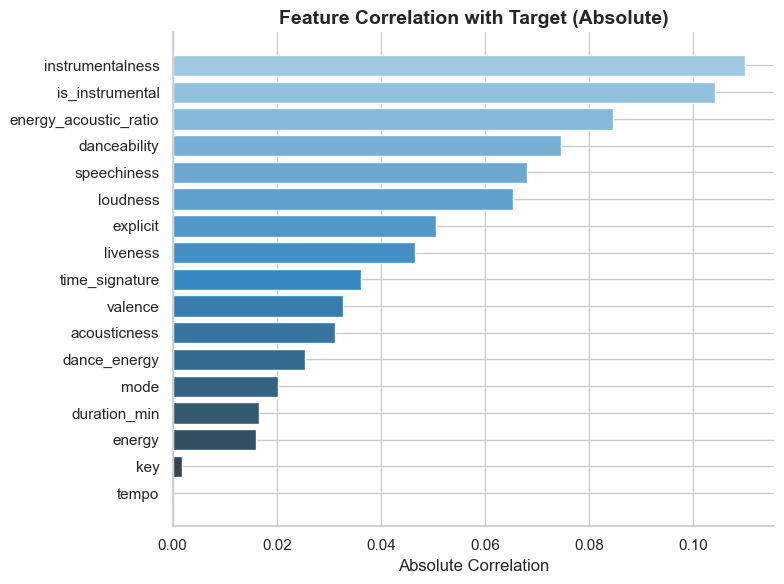

In [61]:
# Feature Correlation with Target
# What features correlate most with the target?
# Correlation only on continuous features — not the sparse genre columns
continuous_cols = [c for c in df.columns 
                   if c != 'target' and not c.startswith('genre_')]

correlations = df[continuous_cols + ['target']].corr()['target'].drop('target')
correlations = correlations.abs().sort_values(ascending=False)

print("=== FEATURE CORRELATION WITH TARGET (absolute) ===")
print(correlations.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(correlations.index, correlations.values,
        color=sns.color_palette('Blues_d', len(correlations)))

ax.set_title('Feature Correlation with Target (Absolute)', fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('images/11_feature_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()

⚠️ Note: Genre columns not shown here (they are binary columns).
- Their individual linear correlations are near zero, but collectively genre is the strongest predictor — confirmed by Random Forest later.

In [62]:
# Class Imbalance Strategy Decision
print("=== CLASS IMBALANCE ANALYSIS ===")
counts = df['target'].value_counts().sort_index()
labels_map = {0: 'Low', 1: 'Medium', 2: 'High'}

for k, v in counts.items():
    print(f"  {labels_map[k]:8s} (class {k}): {v:,} samples  ({v/len(df)*100:.1f}%)")

ratio = counts[0] / counts[2]
print(f"\nImbalance ratio (Low:High) = {ratio:.1f}:1")

=== CLASS IMBALANCE ANALYSIS ===
  Low      (class 0): 67,326 samples  (59.1%)
  Medium   (class 1): 38,149 samples  (33.5%)
  High     (class 2): 8,525 samples  (7.5%)

Imbalance ratio (Low:High) = 7.9:1


📋 STRATEGY DECISION:
   Since High class = only 7.5%:
   - class_weight='balanced' on ALL models
   - Automatically up-weights minority class during training
   - No SMOTE needed — 8,500 High samples sufficient for tree models
   - Primary metric: Weighted F1-Score

## Step 2 (Final): Pre-Model Data Cleanup
Final decisions based on EDA findings — applied before splitting:
| Feature | Action | Reason |
|---------|--------|--------|
| `time_signature` | Drop | 89%+ songs in 4/4 — near-zero variance |
| `instrumentalness` | Drop | Replaced by cleaner `is_instrumental` binary flag |
| `energy_acoustic_ratio` | Log-transform | Extreme right skew even after 99th percentile capping |

In [63]:
# Final Cleanup
df.drop(columns=['time_signature'], inplace=True)
print("✅ Dropped: time_signature (89.3% songs in 4/4 — near-constant)")

df.drop(columns=['instrumentalness'], inplace=True)
print("✅ Dropped: instrumentalness (replaced by is_instrumental binary flag)")

df['energy_acoustic_ratio'] = np.log1p(df['energy_acoustic_ratio'])
print("✅ Log-transformed: energy_acoustic_ratio (fixes extreme right skew)")

genre_cols     = [c for c in df.columns if c.startswith('genre_')]
non_genre_feat = [c for c in df.columns 
                  if not c.startswith('genre_') and c != 'target']

print(f"\n=== FINAL FEATURE SET ===")
print(f"Total rows           : {df.shape[0]:,}")
print(f"Audio features       : {len(non_genre_feat)}")
print(f"Genre OHE columns    : {len(genre_cols)}")
print(f"Total features       : {len(non_genre_feat) + len(genre_cols)}")

print(f"\nAudio features:")
for col in non_genre_feat:
    print(f"  ✅ {col}")

print(f"\nGenre columns: {genre_cols}")

✅ Dropped: time_signature (89.3% songs in 4/4 — near-constant)
✅ Dropped: instrumentalness (replaced by is_instrumental binary flag)
✅ Log-transformed: energy_acoustic_ratio (fixes extreme right skew)

=== FINAL FEATURE SET ===
Total rows           : 114,000
Audio features       : 15
Genre OHE columns    : 4
Total features       : 19

Audio features:
  ✅ explicit
  ✅ danceability
  ✅ energy
  ✅ key
  ✅ loudness
  ✅ mode
  ✅ speechiness
  ✅ acousticness
  ✅ liveness
  ✅ valence
  ✅ tempo
  ✅ duration_min
  ✅ energy_acoustic_ratio
  ✅ dance_energy
  ✅ is_instrumental

Genre columns: ['genre_Hip-Hop_RandB_and_Urban', 'genre_Other', 'genre_Pop_and_Mainstream', 'genre_Rock_and_Metal']


## Step 3: EDA — Summary of Key Findings
| # | Finding | Business Implication |
|---|---------|----------------------|
| 1 | 59% of songs are Low popularity | Record labels must invest very selectively |
| 2 | Pop & Mainstream lead chart-toppers | Genre selection is the highest-leverage commercial decision |
| 3 | High popularity concentrates in high dance + energy | Audio fingerprint predicts mainstream appeal |
| 4 | Explicit songs have ~2× the High popularity rate | Suppressing explicit content may reduce commercial reach |
| 5 | Energy–Acousticness = −0.73 | Features are complementary — both worth keeping |
| 6 | Musical key has near-zero impact on popularity | Key can be deprioritised without predictive loss |
| 7 | 70%+ songs are vocal (instrumentalness < 0.01) | Instrumental releases need a separate niche strategy |
| 8 | All continuous audio feature correlations are weak | Popularity is non-linear — tree models required |

## Step 4: Train / Validation / Test Split
Three-way stratified split:
- **Training set (70%)** — models learn from this
- **Validation set (15%)** — used to compare models without touching test data
- **Test set (15%)** — used exactly once at the end for honest evaluation

`stratify=y` preserves the 59.1 / 33.5 / 7.5 class proportions in all three sets.
This is critical — without it, the rare High class could be underrepresented in the test set, making evaluation unreliable.

In [64]:
# Split
X = df.drop(columns=['target'])
y = df['target']

# Step 1: Carve out 15% test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

# Step 2: Split remainder → 70% train + 15% val
# 0.1765 of remaining 85% ≈ 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print("=== DATA SPLIT SUMMARY ===")
print(f"  Training set   : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  Validation set : {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"  Test set       : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%)")

print("\n=== STRATIFICATION CHECK ===")
print("(All three sets should show ~59.1% / 33.5% / 7.5%)\n")
for name, yset in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    c = yset.value_counts(normalize=True).sort_index().mul(100).round(1)
    print(f"  {name:6s} → Low={c[0]}%  Medium={c[1]}%  High={c[2]}%")

=== DATA SPLIT SUMMARY ===
  Training set   : 79,797 rows (70.0%)
  Validation set : 17,103 rows (15.0%)
  Test set       : 17,100 rows (15.0%)

=== STRATIFICATION CHECK ===
(All three sets should show ~59.1% / 33.5% / 7.5%)

  Train  → Low=59.1%  Medium=33.5%  High=7.5%
  Val    → Low=59.1%  Medium=33.5%  High=7.5%
  Test   → Low=59.1%  Medium=33.5%  High=7.5%


## Step 5: Model Building
Four classifiers, each connecting to a core machine learning concept:
| Model | Key Concept |
|-------|-------------|
| Logistic Regression | Sigmoid function, linear decision boundary |
| Random Forest | Gini Index (CART), Bagging, 200 trees |
| LinearSVC | Large-margin classifier, scalable to 114k rows |
| XGBoost | Gradient Boosting, sequential error correction |

**Pipeline design:**
- `StandardScaler` applied only to continuous audio features.
- OHE genre columns and binary flags passed through unchanged (scaling a binary 0/1 column is mathematically incorrect).
- All models use `class_weight='balanced'` to handle the 7.9:1 class imbalance.

In [65]:
# Feature column groups
genre_cols = [c for c in X_train.columns if c.startswith('genre_')]

# Continuous features — need StandardScaler for LR and SVM
scale_cols = ['danceability', 'energy', 'loudness', 'speechiness',
              'acousticness', 'liveness', 'valence', 'tempo',
              'duration_min', 'energy_acoustic_ratio', 'dance_energy']

# Binary / encoded / OHE features — pass through unchanged
passthrough_cols = ['explicit', 'key', 'mode', 'is_instrumental'] + genre_cols

preprocessor = ColumnTransformer(transformers=[
    ('scale',       StandardScaler(), scale_cols),
    ('passthrough', 'passthrough',    passthrough_cols)
])

# ── Model 1: Logistic Regression ──────────────────────────
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=1000, class_weight='balanced',
                                random_state=42, n_jobs=-1))
])

# ── Model 2: Random Forest ────────────────────────────────
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=200,
                                     criterion='gini',
                                     class_weight='balanced',
                                     random_state=42, n_jobs=-1))
])

# ── Model 3: LinearSVC ────────────────────────────────────
# CalibratedClassifierCV enables predict_proba for soft voting later
svm_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf',  CalibratedClassifierCV(
                LinearSVC(class_weight='balanced',
                          max_iter=2000, random_state=42)))
])

# ── Model 4: XGBoost ──────────────────────────────────────
xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf',  XGBClassifier(n_estimators=200, learning_rate=0.1,
                           max_depth=6, eval_metric='mlogloss',
                           scale_pos_weight=8,   # Low:High ratio ≈ 67326/8525 ≈ 7.9
                           random_state=42, n_jobs=-1))
])

print("✅ All 4 model pipelines defined")
print("   1. Logistic Regression — linear baseline")
print("   2. Random Forest       — Gini + Bagging")
print("   3. LinearSVC           — large-margin, scalable SVM")
print("   4. XGBoost             — gradient boosting")

✅ All 4 model pipelines defined
   1. Logistic Regression — linear baseline
   2. Random Forest       — Gini + Bagging
   3. LinearSVC           — large-margin, scalable SVM
   4. XGBoost             — gradient boosting


### Note on KNN — Why It Was Excluded
KNN was evaluated as a candidate model but excluded due to fundamental constraints at this dataset's scale:
**KNN is a lazy learner** — it stores all 79,797 training rows and at prediction time computes the distance from every test song to every training song across all features. With 114,000 rows and 20 features, this becomes computationally impractical for a production pipeline. `LinearSVC` covers the same large-margin classification concept without this bottleneck.

### 5.1 — Training & Validation Results

In [66]:
models = {
    'Logistic Regression' : lr_pipeline,
    'Random Forest'       : rf_pipeline,
    'LinearSVC'           : svm_pipeline,
    'XGBoost'             : xgb_pipeline
}

val_results = {}

print("=== TRAINING & VALIDATION RESULTS ===\n")

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    wf1 = f1_score(y_val, y_pred, average='weighted')
    mf1 = f1_score(y_val, y_pred, average='macro')
    
    val_results[name] = {'Accuracy': acc, 'Weighted F1': wf1, 'Macro F1': mf1}
    
    print(f"  {name}")
    print(f"    Training time : {elapsed:.1f}s")
    print(f"    Accuracy      : {acc*100:.2f}%")
    print(f"    Weighted F1   : {wf1:.4f}")
    print(f"    Macro F1      : {mf1:.4f}")
    print()

=== TRAINING & VALIDATION RESULTS ===

  Logistic Regression
    Training time : 4.3s
    Accuracy      : 41.99%
    Weighted F1   : 0.4591
    Macro F1      : 0.3814

  Random Forest
    Training time : 7.6s
    Accuracy      : 73.57%
    Weighted F1   : 0.7224
    Macro F1      : 0.6481

  LinearSVC
    Training time : 5.8s
    Accuracy      : 59.57%
    Weighted F1   : 0.5091
    Macro F1      : 0.3205

  XGBoost
    Training time : 2.8s
    Accuracy      : 65.73%
    Weighted F1   : 0.6195
    Macro F1      : 0.4385



### 5.2 — Validation Comparison Chart

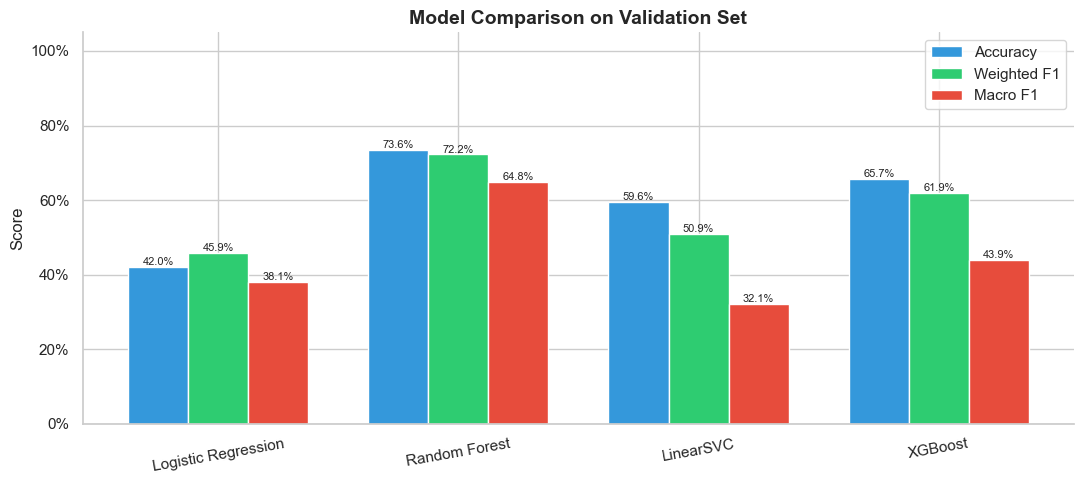

In [67]:
results_df = pd.DataFrame(val_results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'Weighted F1', 'Macro F1']

x     = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, results_df['Accuracy'],    width, label='Accuracy',    color='#3498db')
ax.bar(x,         results_df['Weighted F1'], width, label='Weighted F1', color='#2ecc71')
ax.bar(x + width, results_df['Macro F1'],    width, label='Macro F1',    color='#e74c3c')

for i, row in results_df.iterrows():
    ax.text(i - width, row['Accuracy']    + 0.005, f"{row['Accuracy']*100:.1f}%",    ha='center', fontsize=8)
    ax.text(i,         row['Weighted F1'] + 0.005, f"{row['Weighted F1']*100:.1f}%", ha='center', fontsize=8)
    ax.text(i + width, row['Macro F1']    + 0.005, f"{row['Macro F1']*100:.1f}%",    ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison on Validation Set', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
sns.despine()
plt.tight_layout()
plt.savefig('images/12_model_comparison_validation.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 — Per-Class Performance on Validation Set
Accuracy alone is misleading given the 59/33/7.5 class imbalance. 
The classification report shows Precision, Recall, and F1 **per class** — most importantly how well each model detects the rare **High** popularity class.

In [68]:
print("=== PER-CLASS CLASSIFICATION REPORTS (VALIDATION SET) ===\n")
for name, model in models.items():
    y_pred = model.predict(X_val)
    print(f"── {name} ──")
    print(classification_report(y_val, y_pred, 
                                 target_names=['Low', 'Medium', 'High'], 
                                 digits=3))

=== PER-CLASS CLASSIFICATION REPORTS (VALIDATION SET) ===

── Logistic Regression ──
              precision    recall  f1-score   support

         Low      0.699     0.406     0.513     10101
      Medium      0.430     0.407     0.418      5723
        High      0.130     0.590     0.213      1279

    accuracy                          0.420     17103
   macro avg      0.420     0.468     0.381     17103
weighted avg      0.567     0.420     0.459     17103

── Random Forest ──
              precision    recall  f1-score   support

         Low      0.740     0.891     0.808     10101
      Medium      0.721     0.538     0.616      5723
        High      0.756     0.396     0.520      1279

    accuracy                          0.736     17103
   macro avg      0.739     0.608     0.648     17103
weighted avg      0.735     0.736     0.722     17103

── LinearSVC ──
              precision    recall  f1-score   support

         Low      0.610     0.926     0.735     10101
      Me

## Step 6: Final Evaluation on Test Set
The best model is evaluated on the **held-out test set exactly once**.
This set was never seen during training or model selection — giving an honest, unbiased estimate of real-world performance.

In [69]:
best_name  = max(val_results, key=lambda k: val_results[k]['Weighted F1'])
best_model = models[best_name]

print(f"Best model on validation : {best_name}")
print(f"Weighted F1 (val)        : {val_results[best_name]['Weighted F1']:.4f}\n")

y_test_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_wf1 = f1_score(y_test, y_test_pred, average='weighted')
test_mf1 = f1_score(y_test, y_test_pred, average='macro')

print("=== FINAL TEST SET RESULTS ===")
print(f"  Model       : {best_name}")
print(f"  Accuracy    : {test_acc*100:.2f}%")
print(f"  Weighted F1 : {test_wf1:.4f}")
print(f"  Macro F1    : {test_mf1:.4f}")
print()
print(classification_report(y_test, y_test_pred, 
                              target_names=['Low', 'Medium', 'High'], 
                              digits=3))

Best model on validation : Random Forest
Weighted F1 (val)        : 0.7224

=== FINAL TEST SET RESULTS ===
  Model       : Random Forest
  Accuracy    : 73.95%
  Weighted F1 : 0.7266
  Macro F1    : 0.6534

              precision    recall  f1-score   support

         Low      0.743     0.894     0.811     10099
      Medium      0.730     0.541     0.622      5722
        High      0.735     0.411     0.527      1279

    accuracy                          0.740     17100
   macro avg      0.736     0.615     0.653     17100
weighted avg      0.738     0.740     0.727     17100



### 6.1 — k-Fold Cross Validation
Taught in the XGBoost class notebook (`cross_val_score`, `cv=10`).
Cross-validation verifies that the model's performance is **stable across different data splits** — confirming the result is not a lucky outcome of one particular train/test division.

In [70]:
print("=== k-FOLD CROSS VALIDATION (Best Model: Random Forest) ===")
print("Running 5-Fold CV on training data...\n")

cv_scores = cross_val_score(
    estimator = rf_pipeline,
    X         = X_train,
    y         = y_train,
    cv        = 5,
    scoring   = 'f1_weighted',
    n_jobs    = -1
)

print(f"  CV Weighted F1 per fold : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean Weighted F1        : {cv_scores.mean()*100:.2f}%")
print(f"  Standard Deviation      : {cv_scores.std()*100:.2f}%")

if cv_scores.std() < 0.02:
    print("\n  ✅ Low variance across folds — model is stable and not overfitting.")
else:
    print("\n  ⚠️  High variance across folds — model may be sensitive to data splits.")

=== k-FOLD CROSS VALIDATION (Best Model: Random Forest) ===
Running 5-Fold CV on training data...

  CV Weighted F1 per fold : [np.float64(0.7138), np.float64(0.7124), np.float64(0.7089), np.float64(0.7185), np.float64(0.7042)]
  Mean Weighted F1        : 71.16%
  Standard Deviation      : 0.48%

  ✅ Low variance across folds — model is stable and not overfitting.


### 6.2 — Voting Classifier (Ensemble Hard & Soft Voting)

The Ensemble Learning: - 
- **Hard Voting**: Each model votes for a class, majority wins
- **Soft Voting**: Average probability scores across models, highest wins

In [71]:
print("=== VOTING CLASSIFIER (Ensemble — Hard & Soft Voting) ===\n")

hard_voting = VotingClassifier(
    estimators=[('lr', lr_pipeline), ('rf', rf_pipeline), ('xgb', xgb_pipeline)],
    voting='hard'
)

soft_voting = VotingClassifier(
    estimators=[('lr', lr_pipeline), ('rf', rf_pipeline), ('xgb', xgb_pipeline)],
    voting='soft'
)

print("Training Hard Voting Classifier...")
hard_voting.fit(X_train, y_train)
hard_wf1 = f1_score(y_val, hard_voting.predict(X_val), average='weighted')
print(f"  Validation Weighted F1 : {hard_wf1*100:.2f}%")

print("\nTraining Soft Voting Classifier...")
soft_voting.fit(X_train, y_train)
soft_wf1 = f1_score(y_val, soft_voting.predict(X_val), average='weighted')
print(f"  Validation Weighted F1 : {soft_wf1*100:.2f}%")

print(f"""
=== COMPARISON: Individual vs Voting Ensemble ===
  Logistic Regression alone : {val_results['Logistic Regression']['Weighted F1']*100:.2f}%
  XGBoost alone             : {val_results['XGBoost']['Weighted F1']*100:.2f}%
  Random Forest alone       : {val_results['Random Forest']['Weighted F1']*100:.2f}%
  
  Hard Voting (LR+RF+XGB)   : {hard_wf1*100:.2f}%
  Soft Voting (LR+RF+XGB)   : {soft_wf1*100:.2f}%
""")

=== VOTING CLASSIFIER (Ensemble — Hard & Soft Voting) ===

Training Hard Voting Classifier...
  Validation Weighted F1 : 66.44%

Training Soft Voting Classifier...
  Validation Weighted F1 : 70.65%

=== COMPARISON: Individual vs Voting Ensemble ===
  Logistic Regression alone : 45.91%
  XGBoost alone             : 61.95%
  Random Forest alone       : 72.24%

  Hard Voting (LR+RF+XGB)   : 66.44%
  Soft Voting (LR+RF+XGB)   : 70.65%



Note: In this case, the voting ensemble did not outperform Random Forest alone — 
Logistic Regression's weak performance (45.9%) dragged the ensemble down. 
This is consistent with the ensemble theory caveat that all component models 
should be comparably strong for voting to add value.

### 6.3 — Confusion Matrix

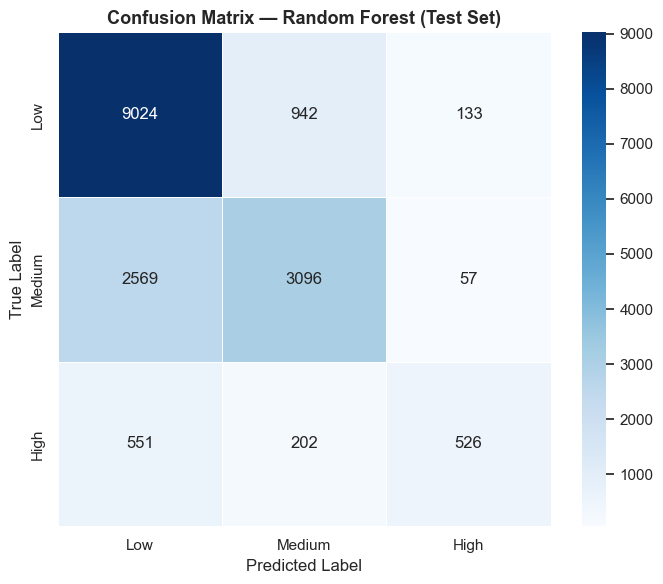

Low  popularity recall : 9024/10099   = 89.4%
High popularity recall : 526/1279 = 41.1%


In [72]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'],
            linewidths=0.5, ax=ax)

ax.set_title(f'Confusion Matrix — {best_name} (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('images/13_confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

total_high   = cm[2].sum()
correct_high = cm[2][2]
total_low    = cm[0].sum()
correct_low  = cm[0][0]

print(f"Low  popularity recall : {correct_low}/{total_low}   = {correct_low/total_low*100:.1f}%")
print(f"High popularity recall : {correct_high}/{total_high} = {correct_high/total_high*100:.1f}%")

### 6.4 — Feature Importance
Random Forest provides direct feature importance scores revealing which features drove the model's predictions most heavily.
Because we consolidated 114 genres into 4 macro-genre columns via One-Hot Encoding, we can aggregate them to see the true impact of "Genre" as a whole.

=== AGGREGATED FEATURE IMPORTANCE ===

  Genre (All Macro Groups Combined) : 0.0342
  duration_min                   : 0.0881
  valence                        : 0.0843
  loudness                       : 0.0842
  speechiness                    : 0.0818
  tempo                          : 0.0814
  danceability                   : 0.0805
  liveness                       : 0.0797
  energy                         : 0.0792
  acousticness                   : 0.0788
  dance_energy                   : 0.0748
  energy_acoustic_ratio          : 0.0747
  key                            : 0.0446
  is_instrumental                : 0.0143
  mode                           : 0.0114
  explicit                       : 0.0077


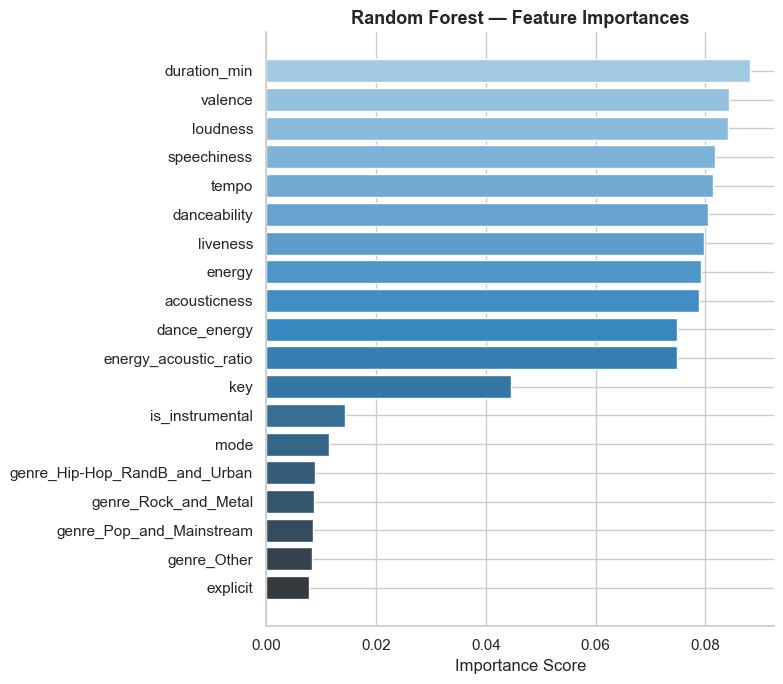


Combined genre importance : 0.0342
Audio features dominate. Genre macro groups combined (0.034) score lower than any individual audio feature.


In [73]:
rf_model      = rf_pipeline.named_steps['clf']
feature_names = scale_cols + passthrough_cols
importances   = rf_model.feature_importances_

imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

# Aggregate genre importance for cleaner display
genre_importance  = imp_df[imp_df['Feature'].str.startswith('genre_')]['Importance'].sum()
other_importance  = imp_df[~imp_df['Feature'].str.startswith('genre_')]

print("=== AGGREGATED FEATURE IMPORTANCE ===")
print(f"\n  Genre (All Macro Groups Combined) : {genre_importance:.4f}")
for _, row in other_importance.iterrows():
    print(f"  {row['Feature']:30s} : {row['Importance']:.4f}")

# Plot top individual features
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_df['Feature'], imp_df['Importance'], color=sns.color_palette('Blues_d', len(imp_df)))
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('images/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCombined genre importance : {genre_importance:.4f}")
print("Audio features dominate. Genre macro groups combined (0.034) score lower than any individual audio feature.")

## Step 7: Prediction & Deployment Simulation
A new, unseen song enters the system. Based on its audio profile, the model predicts whether it will be a chart-topper, mainstream, or niche track.
This simulates how a record label would use the model in a production workflow.

In [74]:
# Build the genre OHE row manually
# We want to simulate a "Pop & Mainstream" song. 
pop_col = 'genre_Pop_and_Mainstream'

# Start with all genre columns = 0
genre_row = {col: 0 for col in genre_cols}
if pop_col in genre_row:
    genre_row[pop_col] = 1  # this song is pop

new_song_data = {
    'danceability'         : 0.82,
    'energy'               : 0.78,
    'loudness'             : -4.5,
    'speechiness'          : 0.08,
    'acousticness'         : 0.05,
    'liveness'             : 0.12,
    'valence'              : 0.71,
    'tempo'                : 124.0,
    'duration_min'         : 3.4,
    'energy_acoustic_ratio': np.log1p(0.78 / (0.05 + 0.001)),
    'dance_energy'         : 0.82 * 0.78,
    'explicit'             : 0,
    'key'                  : 5,
    'mode'                 : 1,
    'is_instrumental'      : 0
}
# Merge audio features with genre columns
new_song_data.update(genre_row)

new_song = pd.DataFrame([new_song_data])

# Ensure column order perfectly matches the training data
new_song = new_song[X_train.columns]

prediction    = best_model.predict(new_song)[0]
probabilities = best_model.predict_proba(new_song)[0]
label_map     = {0: 'Low', 1: 'Medium', 2: 'High'}

print("=== DEPLOYMENT SIMULATION ===")
print("\nInput Song Profile:")
print("  Danceability : 0.82  (very danceable)")
print("  Energy       : 0.78  (high intensity)")
print("  Loudness     : -4.5 dB  (mastered for streaming)")
print("  Valence      : 0.71  (positive, upbeat mood)")
print("  Tempo        : 124 BPM  (dance-floor tempo)")
print("  Genre        : Pop & Mainstream | Explicit: No | Instrumental: No")

print(f"\nModel Prediction    : {label_map[prediction]} Popularity")
print(f"\nConfidence Scores:")
print(f"  Low    : {probabilities[0]*100:.1f}%")
print(f"  Medium : {probabilities[1]*100:.1f}%")
print(f"  High   : {probabilities[2]*100:.1f}%")

# Recommendation always reflects actual model output
if prediction == 2:
    rec = ("  This song's profile aligns perfectly with chart-topping tracks.\n"
           "  Recommendation: Proceed with full marketing investment.")
elif prediction == 1:
    rec = ("  This song is predicted as mainstream but not a chart-topper.\n"
           "  Recommendation: Moderate investment. Focus on playlist placement\n"
           "  and organic discovery before committing to a full campaign.")
else:
    rec = ("  Despite strong audio features, the model predicts Low popularity.\n"
           "  The overall profile does not match historically high-performing\n"
           "  tracks in this dataset.\n"
           "  Recommendation: Hold mainstream investment. Consider niche playlist\n"
           "  targeting or A/B testing before committing full campaign budget.")

print(f"\nBusiness Recommendation:\n{rec}")

=== DEPLOYMENT SIMULATION ===

Input Song Profile:
  Danceability : 0.82  (very danceable)
  Energy       : 0.78  (high intensity)
  Loudness     : -4.5 dB  (mastered for streaming)
  Valence      : 0.71  (positive, upbeat mood)
  Tempo        : 124 BPM  (dance-floor tempo)
  Genre        : Pop & Mainstream | Explicit: No | Instrumental: No

Model Prediction    : Low Popularity

Confidence Scores:
  Low    : 45.0%
  Medium : 21.5%
  High   : 33.5%

Business Recommendation:
  Despite strong audio features, the model predicts Low popularity.
  The overall profile does not match historically high-performing
  tracks in this dataset.
  Recommendation: Hold mainstream investment. Consider niche playlist
  targeting or A/B testing before committing full campaign budget.
